# Introduction
This Colab worksheet provides a starting point for Task 2 (the computer vision task).

# Data Loading

In [ ]:
# Download the data stored in a zipped numpy array
# If you're running all your experiments on a machine at home rather than using colab, then make sure you save it rather than repeatedly downloading it.

# training images
!wget "https://sussex.box.com/shared/static/f0t5ikvkespe69oj2v7ujs04ub1g7mfz.npz" -O face_alignment_training_data.npz
# validation images
!wget "https://sussex.box.com/shared/static/atl7foe43vynfjlczy520ct54kclf599.npz" -O face_alignment_validation_data.npz
# test images (without points)
!wget "https://sussex.box.com/shared/static/7wb1dxcyt01nqvxh44m3e7ux6iv5q0ov.npz" -O face_alignment_test_data.npz

--2026-07-31 13:22:04--  https://sussex.box.com/shared/static/f0t5ikvkespe69oj2v7ujs04ub1g7mfz.npz
Resolving sussex.box.com (sussex.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.box.com (sussex.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/f0t5ikvkespe69oj2v7ujs04ub1g7mfz.npz [following]
--2026-07-31 13:22:04--  https://sussex.box.com/public/static/f0t5ikvkespe69oj2v7ujs04ub1g7mfz.npz
Reusing existing connection to sussex.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://sussex.app.box.com/public/static/f0t5ikvkespe69oj2v7ujs04ub1g7mfz.npz [following]
--2026-07-31 13:22:04--  https://sussex.app.box.com/public/static/f0t5ikvkespe69oj2v7ujs04ub1g7mfz.npz
Resolving sussex.app.box.com (sussex.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.app.box.com (sussex.app.box.com)|74.112.186.157|:443... connected.
HTTP request

# Load the data

In [ ]:
import numpy as np

# Load the training data using np.load
data_train = np.load('face_alignment_training_data.npz', allow_pickle=True)
# Extract the images
images_train = data_train['images']
# and the data points
pts_train = data_train['points']
print(images_train.shape, pts_train.shape)

# same for validation data
data_val = np.load('face_alignment_validation_data.npz', allow_pickle=True)
images_val = data_val['images']
pts_val = data_val['points']
print(images_val.shape, pts_val.shape)

# same for test data (without labels)
data_test = np.load('face_alignment_test_data.npz', allow_pickle=True)
images_test = data_test['images']
print(images_test.shape)

(2600, 256, 256, 3) (2600, 5, 2)
(211, 256, 256, 3) (211, 5, 2)
(554, 256, 256, 3)


# Data Visualisation
Here's an example of how to display the images and their points

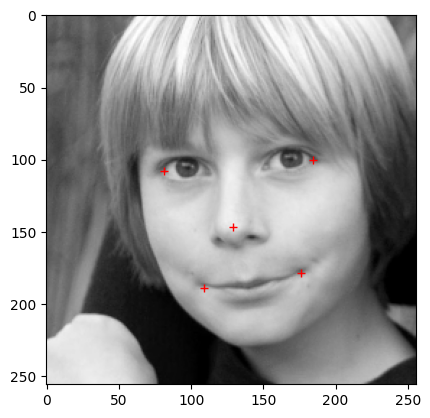

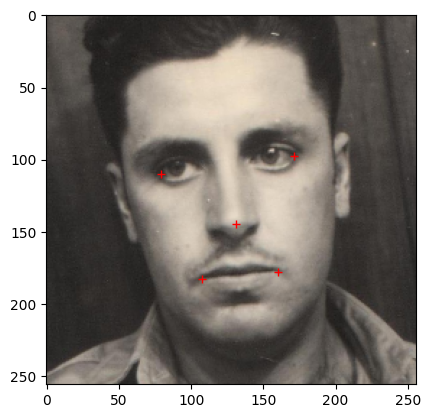

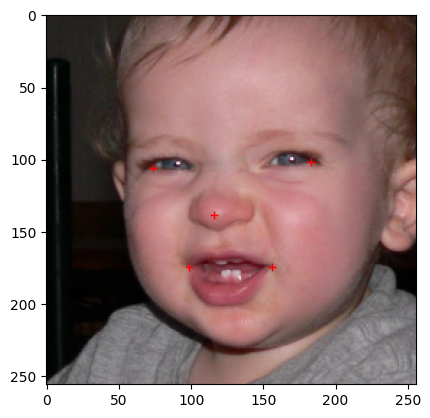

In [ ]:

def visualise_pts(img, pts):
  import matplotlib.pyplot as plt
  plt.imshow(img)
  plt.plot(pts[:, 0], pts[:, 1], '+r')
  plt.show()

for i in range(3):
  idx = np.random.randint(0, images_train.shape[0])
  visualise_pts(images_train[idx, ...], pts_train[idx, ...])

# Calculating Prediction Error and exporting results

In [ ]:
def euclid_dist(pred_pts, gt_pts):
  """
  Calculate the euclidean distance between pairs of points
  :param pred_pts: The predicted points
  :param gt_pts: The ground truth points
  :return: An array of shape (no_points,) containing the distance of each predicted point from the ground truth
  """
  import numpy as np
  pred_pts = np.reshape(pred_pts, (-1, 2))
  gt_pts = np.reshape(gt_pts, (-1, 2))
  return np.sqrt(np.sum(np.square(pred_pts - gt_pts), axis=-1))


In [ ]:
def save_as_csv(points, location = '.'):
    """
    Save the points out as a .csv file
    :param points: numpy array of shape (no_test_images, no_points, 2) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert points.shape[0]==554, 'wrong number of image points, should be 554 test images'
    assert np.prod(points.shape[1:])==5*2, 'wrong number of points provided. There should be 5 points with 2 values (x,y) per point'
    np.savetxt(location + '/results_task2.csv', np.reshape(points, (points.shape[0], -1)), delimiter=',')
